# Dataset Cybersecurity Intrusion

Comment identifier une attaque en fonction de leur caractéristique reseau ?

## 1 - Setup

In [45]:
import os
import glob
from pyexpat import features

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## 2 - Chargement du dataset

In [46]:
df = pd.read_csv("cybersecurity_intrusion_data.csv")

## 3 - Exploration des données

In [47]:
df

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,NaN,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


## 4 - Data Cleaning

In [48]:
def df_clean():
    df_c = df.copy()

    df_c.drop(columns=['session_id'], inplace=True)
    df_c = pd.get_dummies(df_c, columns=['encryption_used'], prefix='is')
    df_c = pd.get_dummies(df_c, columns=['browser_type'], prefix='used')
    df_c = pd.get_dummies(df_c, columns=['protocol_type'], prefix='used')
    
    return df_c

df_cleaned = pd.DataFrame()
df_cleaned = df_clean()
df_cleaned

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,is_AES,is_DES,used_Chrome,used_Edge,used_Firefox,used_Safari,used_Unknown,used_ICMP,used_TCP,used_UDP
0,599,4,492.983263,0.606818,1,0,1,False,True,False,True,False,False,False,False,True,False
1,472,3,1557.996461,0.301569,0,0,0,False,True,False,False,True,False,False,False,True,False
2,629,3,75.044262,0.739164,2,0,1,False,True,True,False,False,False,False,False,True,False
3,804,4,601.248835,0.123267,0,0,1,False,True,False,False,False,False,True,False,False,True
4,453,5,532.540888,0.054874,1,0,0,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9532,194,3,226.049889,0.517737,3,0,1,True,False,True,False,False,False,False,True,False,False
9533,380,3,182.848475,0.408485,0,0,0,False,False,True,False,False,False,False,False,True,False
9534,664,5,35.170248,0.359200,1,0,0,True,False,False,False,True,False,False,False,True,False
9535,406,4,86.664703,0.537417,1,1,0,True,False,True,False,False,False,False,False,True,False


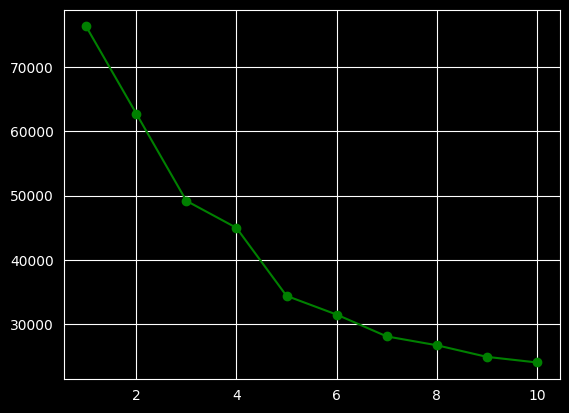

In [49]:
features = df_cleaned[['session_duration', 'login_attempts', 'failed_logins', 'is_AES', 'is_DES', 'used_ICMP', 'used_TCP', 'used_UDP']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

inertias = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, marker='o', color='green')

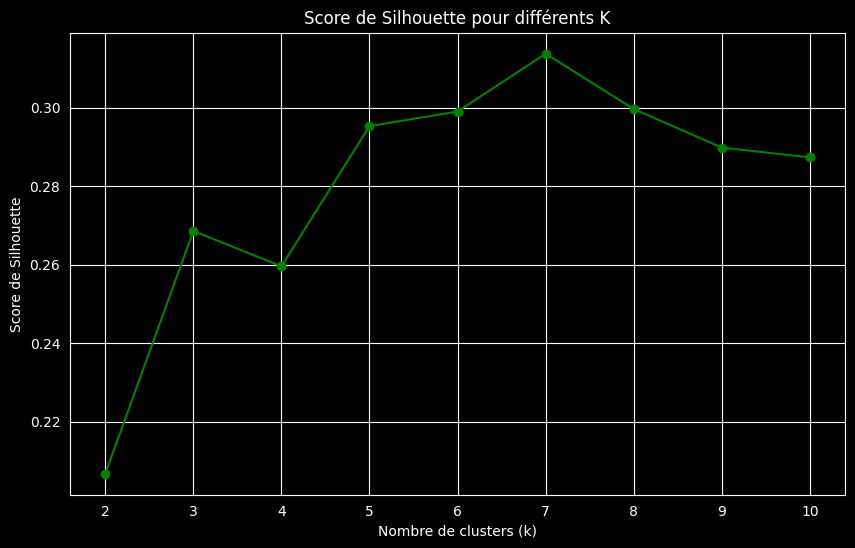

In [50]:
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, labels))

# Trace la courbe du score de silhouette
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title("Score de Silhouette pour différents K")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de Silhouette")
plt.grid(True)
plt.show()

In [51]:
Q1 = df_cleaned['session_duration'].quantile(0.25)
Q3 = df_cleaned['session_duration'].quantile(0.75)
IQR = Q3 - Q1

# Définis les bornes pour filtrer les outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtre le DataFrame pour supprimer les outliers
df_cleaned_no_outliers = df_cleaned[
    (df_cleaned['session_duration'] >= lower_bound) &
    (df_cleaned['session_duration'] <= upper_bound)
]

Q1 = df_cleaned['login_attempts'].quantile(0.25)
Q3 = df_cleaned['login_attempts'].quantile(0.75)
IQR = Q3 - Q1

# Définis les bornes pour filtrer les outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtre le DataFrame pour supprimer les outliers
df_cleaned_no_outliers = df_cleaned[
    (df_cleaned['login_attempts'] >= lower_bound) &
    (df_cleaned['login_attempts'] <= upper_bound)
]

Q1 = df_cleaned['failed_logins'].quantile(0.25)
Q3 = df_cleaned['failed_logins'].quantile(0.75)
IQR = Q3 - Q1

# Définis les bornes pour filtrer les outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtre le DataFrame pour supprimer les outliers
df_cleaned_no_outliers = df_cleaned[
    (df_cleaned['failed_logins'] >= lower_bound) &
    (df_cleaned['failed_logins'] <= upper_bound)
]

df_cleaned_no_outliers

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,is_AES,is_DES,used_Chrome,used_Edge,used_Firefox,used_Safari,used_Unknown,used_ICMP,used_TCP,used_UDP
0,599,4,492.983263,0.606818,1,0,1,False,True,False,True,False,False,False,False,True,False
1,472,3,1557.996461,0.301569,0,0,0,False,True,False,False,True,False,False,False,True,False
2,629,3,75.044262,0.739164,2,0,1,False,True,True,False,False,False,False,False,True,False
3,804,4,601.248835,0.123267,0,0,1,False,True,False,False,False,False,True,False,False,True
4,453,5,532.540888,0.054874,1,0,0,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9531,746,7,315.151758,0.190059,3,0,1,False,True,True,False,False,False,False,False,True,False
9532,194,3,226.049889,0.517737,3,0,1,True,False,True,False,False,False,False,True,False,False
9533,380,3,182.848475,0.408485,0,0,0,False,False,True,False,False,False,False,False,True,False
9534,664,5,35.170248,0.359200,1,0,0,True,False,False,False,True,False,False,False,True,False


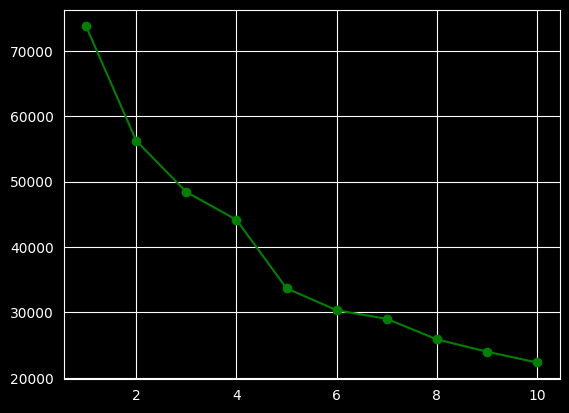

In [52]:
features = df_cleaned_no_outliers[['session_duration', 'login_attempts', 'failed_logins', 'is_AES', 'is_DES', 'used_ICMP', 'used_TCP', 'used_UDP']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

inertias = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, marker='o', color='green')

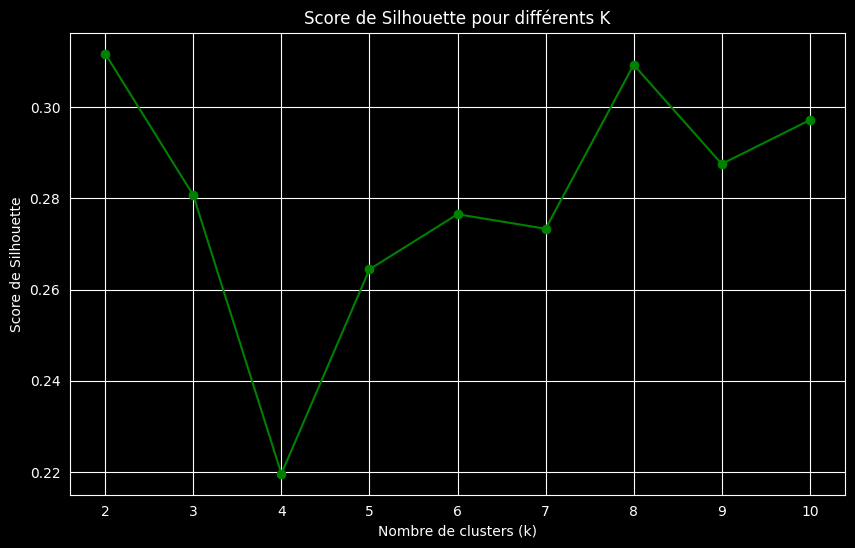

In [53]:
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, labels))

# Trace la courbe du score de silhouette
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title("Score de Silhouette pour différents K")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de Silhouette")
plt.grid(True)
plt.show()